# MLDoctor - Case1
For a high-end grooming application, the engineering team developed a model to discern clean-shaven faces. During the “Lab Phase,” the model performed exceptionally well, trained and validated on studio-quality images. It achieved a near-perfect accuracy on the Internal test Set. However, once deployed in a mobile application, the model’s accuracy significantly decreased. Users have reported that the model frequently fails. What happened during the transition from the “Studio” to the “Mobile App”? Please elaborate on the identified problem, explain how it was identified, and provide a recommended solution. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cuda:0


## Data

In [2]:
# Load the full training dataset first (without transforms for now)
test_internal_dataset = torchvision.datasets.ImageFolder('Case1Dataset/test_internal')
print(f'Internal test dataset size: {len(test_internal_dataset)}')
test_external_dataset = torchvision.datasets.ImageFolder('Case1Dataset/test_external')
print(f'External test dataset size: {len(test_external_dataset)}')

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Apply transforms to the datasets
test_internal_dataset.transform = transform
test_external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(test_internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 0)
test_external_loader = torch.utils.data.DataLoader(test_external_dataset, batch_size=batch_size, shuffle=False, num_workers = 0)

Internal test dataset size: 841
External test dataset size: 740


## Developed Model

In [3]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

# setup the model
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)

# Load the developed model
resnet_frozen.load_state_dict(torch.load("resnet_frozen_best.pth"))
resnet_frozen.eval()
resnet_frozen = resnet_frozen.to(device)
print(resnet_frozen)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /tmp/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 321MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Evaluation

In [4]:
# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [test_internal_loader, test_external_loader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 47/47 [00:04<00:00,  9.70it/s]

Evaluation complete.
internal set - Accuracy: 0.937
external set - Accuracy: 0.619


### This is where i will check the dataset 

In [7]:
## Checking dataset information 

all_predictions['internal']
all_predictions['external']

all_labels['internal']
all_labels['external']

for split in ['internal', 'external']:
    labels = all_labels[split]

    print(f"\n{split.upper()} DATASET")
    print(f"Number of samples: {len(labels)}")
    print(f"Label shape: {labels.shape}")
    print(f"Unique labels: {np.unique(labels, return_counts=True)}")


INTERNAL DATASET
Number of samples: 841
Label shape: (841,)
Unique labels: (array([0, 1]), array([421, 420]))

EXTERNAL DATASET
Number of samples: 740
Label shape: (740,)
Unique labels: (array([0, 1]), array([370, 370]))


In [12]:
## We want to confirm the class mappings 

print(test_internal_loader.dataset.classes)
print(test_external_loader.dataset.classes)

['negative', 'positive']
['negative', 'positive']


In [13]:
## Check for class distribution 

from collections import Counter

for split in ['internal', 'external']:
    counts = Counter(all_labels[split])

    print(f"\n{split.upper()}")
    for label, count in sorted(counts.items()):
        percentage = count / len(all_labels[split]) * 100
        print(f"Class {label}: {count} ({percentage:.2f}%)")


INTERNAL
Class 0: 421 (50.06%)
Class 1: 420 (49.94%)

EXTERNAL
Class 0: 370 (50.00%)
Class 1: 370 (50.00%)


In [14]:
for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)

    unique, counts = np.unique(predicted_classes, return_counts=True)

    print(f"\n{split.upper()} PREDICTIONS")

    for label, count in zip(unique, counts):
        percentage = count / len(predicted_classes) * 100
        print(f"Class {label}: {count} ({percentage:.2f}%)")


INTERNAL PREDICTIONS
Class 0: 398 (47.32%)
Class 1: 443 (52.68%)

EXTERNAL PREDICTIONS
Class 0: 96 (12.97%)
Class 1: 644 (87.03%)


### This is where i will check the models 

In [21]:
## imports 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



===== INTERNAL =====
Samples: 841
True labels: (array([0, 1]), array([421, 420]))
Predicted labels: (array([0, 1]), array([398, 443]))
Confusion matrix:

===== EXTERNAL =====
Samples: 740
True labels: (array([0, 1]), array([370, 370]))
Predicted labels: (array([0, 1]), array([ 96, 644]))
Confusion matrix:


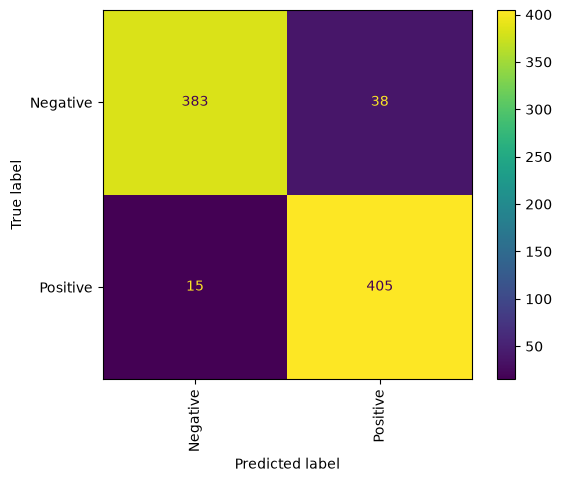

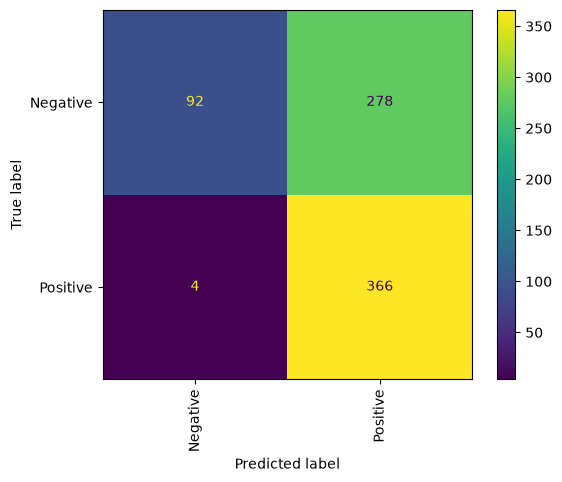

In [22]:
for split in ['internal', 'external']:

    labels = all_labels[split]
    predictions = all_predictions[split]
    predicted_classes = np.argmax(predictions, axis=1)

    print(f"\n===== {split.upper()} =====")

    print("Samples:", len(labels))
    print("True labels:", np.unique(labels, return_counts=True))
    print("Predicted labels:", np.unique(predicted_classes, return_counts=True))
    print("Confusion matrix:")
    print(ConfusionMatrixDisplay.from_predictions(labels, predicted_classes, display_labels=['Negative', 'Positive'], xticks_rotation='vertical'))

In [23]:
for split in ['internal', 'external']:

    labels = all_labels[split]
    predictions = all_predictions[split]
    predicted_classes = np.argmax(predictions, axis=1)

    print(f"\n===== {split.upper()} =====")

    print(classification_report(
        labels,
        predicted_classes,
        target_names=['Negative', 'Positive'],
        digits=3
    ))


===== INTERNAL =====
              precision    recall  f1-score   support

    Negative      0.962     0.910     0.935       421
    Positive      0.914     0.964     0.939       420

    accuracy                          0.937       841
   macro avg      0.938     0.937     0.937       841
weighted avg      0.938     0.937     0.937       841


===== EXTERNAL =====
              precision    recall  f1-score   support

    Negative      0.958     0.249     0.395       370
    Positive      0.568     0.989     0.722       370

    accuracy                          0.619       740
   macro avg      0.763     0.619     0.558       740
weighted avg      0.763     0.619     0.558       740



### Testing a theory based on an observation

In [35]:
import cv2
import numpy as np

def calculate_sharpness(image):

    # Tensor -> NumPy
    image = image.detach().cpu().numpy()

    # C x H x W -> H x W x C
    image = np.transpose(image, (1, 2, 0))

    # Convert RGB -> grayscale
    image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Ensure correct datatype
    image = image.astype(np.float32)

    # Calculate sharpness
    return cv2.Laplacian(image, cv2.CV_32F).var()

In [36]:
internal_sharpness = []

for image, label in test_internal_dataset:
    internal_sharpness.append(calculate_sharpness(image))

external_sharpness = []

for image, label in test_external_dataset:
    external_sharpness.append(calculate_sharpness(image))

In [37]:
print("Internal:", len(internal_sharpness))
print("External:", len(external_sharpness))

print("\nINTERNAL")
print("Mean:", np.mean(internal_sharpness))
print("Median:", np.median(internal_sharpness))

print("\nEXTERNAL")
print("Mean:", np.mean(external_sharpness))
print("Median:", np.median(external_sharpness))

Internal: 841
External: 740

INTERNAL
Mean: 0.07257213
Median: 0.057028167

EXTERNAL
Mean: 0.010899019
Median: 0.008813683


#### Identified Problem 

The transition from the studio to the mobile app introduced a significant data distribution shif, specifically in image quality. The model achieved 93.7% accuracy on the Internal dataset but decreased to 61.9% on the 740 image external data set. 

Analysis of the External confusion matrix (Figure 1) indicated that this degradation was primarily caused by false positive classifications. Of the 370 genuinely negative images (Facial hair) 278 (75.1%) were incorrectly classified as clean shaven. This resulted in a Negative class recall of only 24.9%, compared with the 98.9% for the positicve class (as shwon in Figure 2), indicating a strong positive class bias. 

#### Identification 

Following the analysis of the classification errors, a quick visual inspection of the Internal and External datasets identified a noticeable difference in image quality. The studio images were generally clearerand sharper, where as external images showed a noticeable difference. This observation was tested quantitatively, using a variance, of the laplacian as an image sharpness measure. The internal dataset produced a mean sharpness of 0.0726, compared to 0.019 for the external dataset, this represented an 85% reduction in measured sharpness. Median sharpness similarly decreased from 0.0570 to 0.0088. These results provide quantitative evidence that the External dataset contains substantially lower-quality images than the Studio dataset.

Therefore the evidence suggested that the models reduced mobile performance is associated with a domain/image quality shift between the studio training and the Mobile deployment environment, with the lower quality images potenitally hiding the fine grained facial features required by the model to distinguish, clean shaven from non-clean shaven. 

#### Recommended Solution
The recommended solution is to address both the input quality and model robustness. The Mobile application should implement image-quality guidance and, where appropriate, automatically detect excessively blurred images and request the user to retake them. Additionally, the model should be fine-tuned using representative Mobile images and augmented with realistic blur and other Mobile-specific image distortions. The resulting model should then be evaluated against an independent External test set to verify that performance has improved under real deployment conditions.